# Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import (
    OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler, PolynomialFeatures
)
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns


##Import Data

In [2]:
df=pd.read_csv("company_employee_details.csv")
df.head()

,Unnamed: 0,company,department,employee_id,age,age_when_joined,years_in_the_company,salary,annual_bonus,prior_years_experience,full_time,part_time,contractor
0,0,Glasses,BigData,16,41,38,3,68074.971354,17664.104103,3,0.000000,0.000000,1.000000
1,1,Glasses,AI,56,44,42,2,49092.147458,21551.141079,2,0.000000,0.184991,1.000000
2,2,Cheerper,Support,59,41,40,1,40000.000000,23698.878851,2,0.000000,0.919887,0.662706
3,3,Glasses,Design,40,39,32,7,108192.465506,21570.929657,1,0.930396,0.546206,0.000000
4,4,Glasses,Search Engine,47,30,22,9,71291.191132,21565.505715,2,0.525432,0.938412,0.000000


In [3]:
# --------- Distribution of numeric features ----------
numeric_cols = ['age','age_when_joined','years_in_the_company',
                'salary','annual_bonus','prior_years_experience']

#Checking Null Values

In [4]:
print(df.isnull().values.any())

False


#EDA

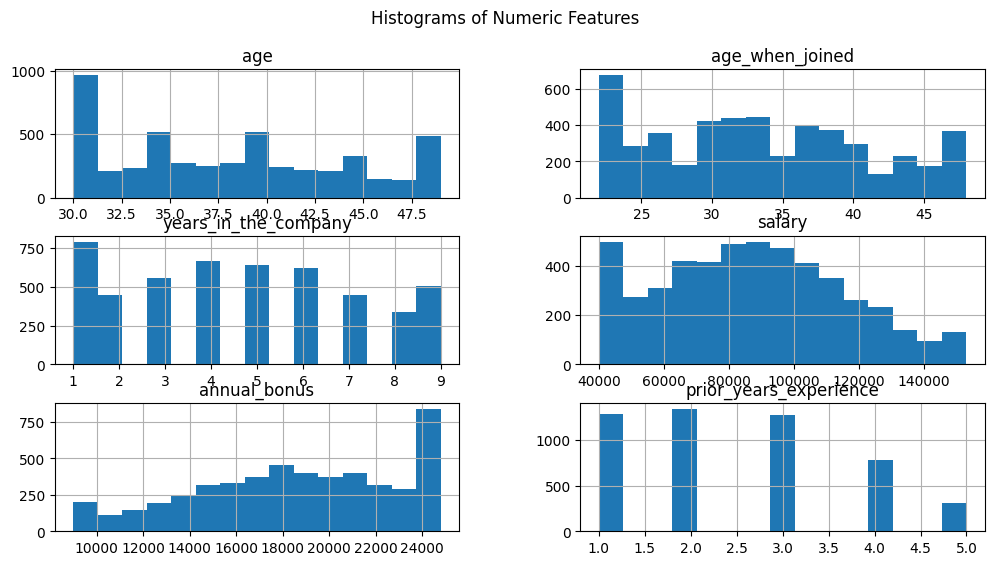

In [5]:
df[numeric_cols].hist(bins=15, figsize=(12,6))
plt.suptitle("Histograms of Numeric Features")
plt.show()

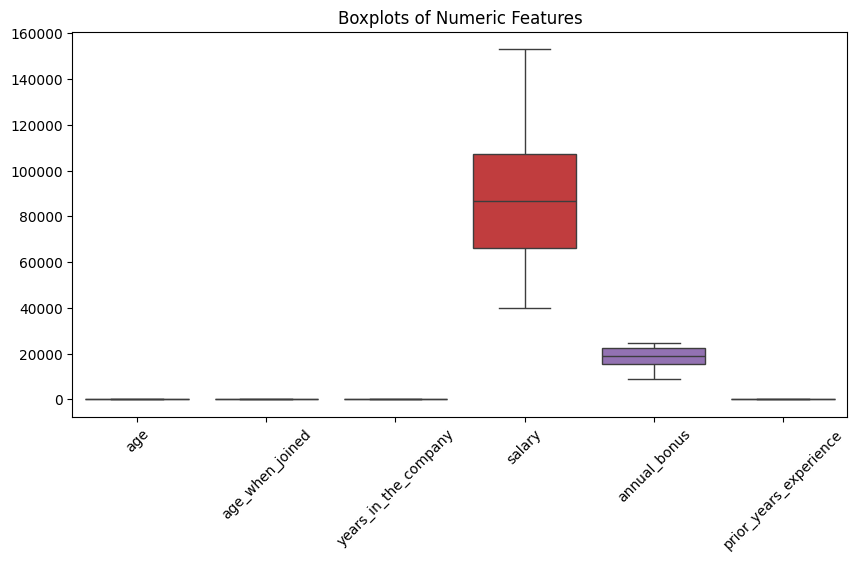

In [6]:
# --------- Boxplots (detect outliers) ----------
plt.figure(figsize=(10,5))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplots of Numeric Features")
plt.xticks(rotation=45)
plt.show()

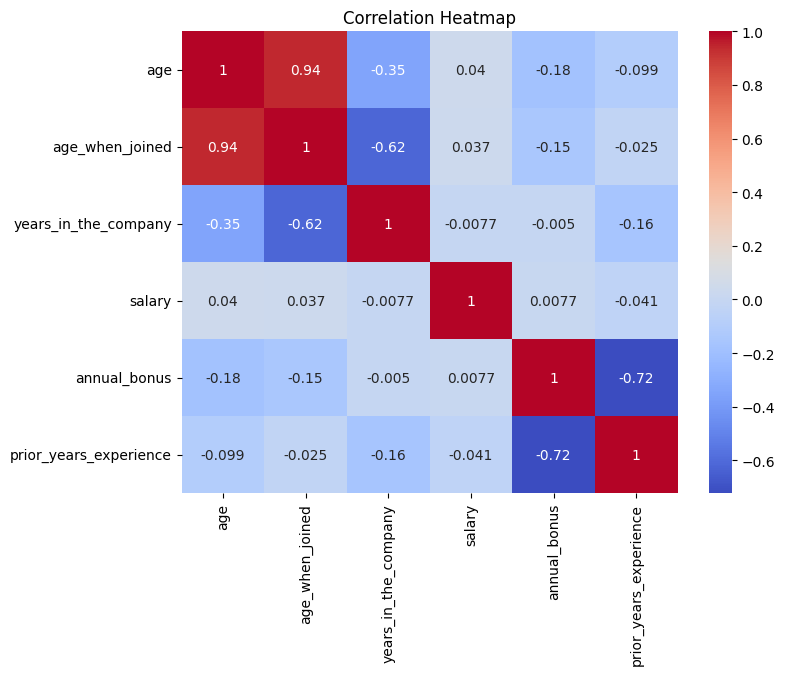

In [7]:
# --------- Correlation heatmap ----------
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

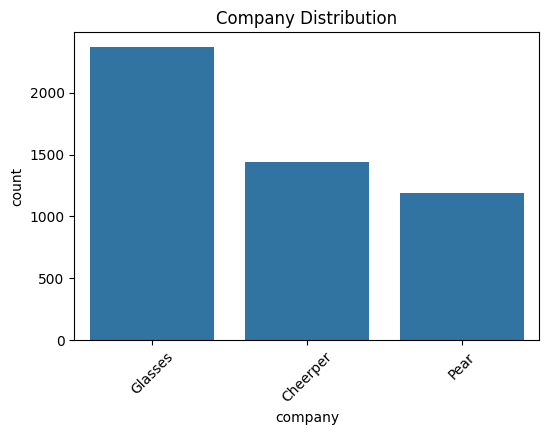

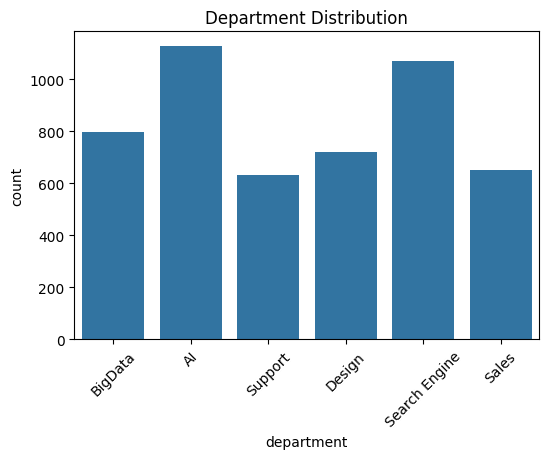

In [8]:
# --------- Count plots for categoricals ----------
plt.figure(figsize=(6,4))
sns.countplot(x='company', data=df)
plt.title("Company Distribution")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='department', data=df)
plt.title("Department Distribution")
plt.xticks(rotation=45)
plt.show()

# Feature Engineering

In [9]:

# ============= 1. Handle Missing Values =============
num_cols = numeric_cols
cat_cols = ['company','department']

In [10]:
# numeric imputation
num_imputer = SimpleImputer(strategy='mean')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [11]:
# ============= 2. Encode Categorical =============
# Label encode company (few categories)
le_company = LabelEncoder()
df['company_encoded'] = le_company.fit_transform(df['company'])

In [12]:
# One-hot encode department
ohe = OneHotEncoder(sparse_output=False, drop='first')
dept_encoded = ohe.fit_transform(df[['department']])
dept_df = pd.DataFrame(dept_encoded, columns=ohe.get_feature_names_out(['department']))
df = pd.concat([df, dept_df], axis=1)

In [13]:
# ============= 3. Scale numerical features =============
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[num_cols])
df_scaled = pd.DataFrame(df_scaled, columns=[col+'_scaled' for col in num_cols])
df = pd.concat([df, df_scaled], axis=1)

In [14]:
df

,Unnamed: 0,company,department,employee_id,age,age_when_joined,years_in_the_company,salary,annual_bonus,prior_years_experience,...,department_Design,department_Sales,department_Search Engine,department_Support,age_scaled,age_when_joined_scaled,years_in_the_company_scaled,salary_scaled,annual_bonus_scaled,prior_years_experience_scaled
0,0,Glasses,BigData,16,41.0,38.0,3.0,68074.971354,17664.104103,3.0,...,0.0,0.0,0.0,0.0,0.474904,0.578828,-0.652404,-0.672715,-0.212744,0.416590
1,1,Glasses,AI,56,44.0,42.0,2.0,49092.147458,21551.141079,2.0,...,0.0,0.0,0.0,0.0,0.971630,1.093868,-1.044946,-1.341485,0.668330,-0.412610
2,2,Cheerper,Support,59,41.0,40.0,1.0,40000.000000,23698.878851,2.0,...,0.0,0.0,0.0,1.0,0.474904,0.836348,-1.437488,-1.661804,1.155158,-0.412610
3,3,Glasses,Design,40,39.0,32.0,7.0,108192.465506,21570.929657,1.0,...,1.0,0.0,0.0,0.0,0.143753,-0.193732,0.917763,0.740635,0.672816,-1.241809
4,4,Glasses,Search Engine,47,30.0,22.0,9.0,71291.191132,21565.505715,2.0,...,0.0,0.0,1.0,0.0,-1.346427,-1.481332,1.702846,-0.559407,0.671586,-0.412610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,Cheerper,Search Engine,37,42.0,35.0,7.0,76541.841502,17366.896122,2.0,...,0.0,0.0,1.0,0.0,0.640479,0.192548,0.917763,-0.374425,-0.280112,-0.412610
4996,4996,Glasses,AI,1,36.0,25.0,9.0,113651.485089,20888.144794,1.0,...,0.0,0.0,0.0,0.0,-0.352974,-1.095052,1.702846,0.932958,0.518049,-1.241809
4997,4997,Glasses,Search Engine,20,35.0,30.0,5.0,77560.047560,24792.910000,2.0,...,0.0,0.0,1.0,0.0,-0.518550,-0.451252,0.132679,-0.338553,1.403142,-0.412610
4998,4998,Pear,Sales,9,49.0,48.0,1.0,153000.000000,11700.850325,4.0,...,0.0,1.0,0.0,0.0,1.799508,1.866428,-1.437488,2.319217,-1.564435,1.245789


In [15]:
# ============= 4. Feature Construction =============
# Age gap (current age - age when joined)
df['age_gap'] = df['age'] - df['age_when_joined']

In [16]:
# Experience efficiency (salary per year of experience)
df['salary_per_exp'] = df['salary'] / (df['prior_years_experience']+df['years_in_the_company']+1)

In [19]:
# ============= 5. Feature Selection =============
X = df[num_cols + ['company_encoded'] + list(dept_df.columns)]
y = df['salary']  # You can change target depending on your use case

selector = SelectKBest(score_func=f_classif, k=6)
selector.fit(X, y)
print("Top 5 selected features:", X.columns[selector.get_support()].tolist())

Top 5 selected features: ['age', 'salary', 'company_encoded', 'department_Design', 'department_Sales', 'department_Search Engine']


D:\new_compant\Training\test\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


In [20]:
# ============= 6. PCA (Dimensionality Reduction) =============
scaled_for_pca = scaler.fit_transform(df[num_cols])
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_for_pca)
df['pca_1'] = pca_result[:,0]
df['pca_2'] = pca_result[:,1]

print("\nFinal Data with Engineered Features:\n", df.head())


Final Data with Engineered Features:
    Unnamed: 0   company     department  employee_id   age  age_when_joined  \
0           0   Glasses        BigData           16  41.0             38.0   
1           1   Glasses             AI           56  44.0             42.0   
2           2  Cheerper        Support           59  41.0             40.0   
3           3   Glasses         Design           40  39.0             32.0   
4           4   Glasses  Search Engine           47  30.0             22.0   

   years_in_the_company         salary  annual_bonus  prior_years_experience  \
0                   3.0   68074.971354  17664.104103                     3.0   
1                   2.0   49092.147458  21551.141079                     2.0   
2                   1.0   40000.000000  23698.878851                     2.0   
3                   7.0  108192.465506  21570.929657                     1.0   
4                   9.0   71291.191132  21565.505715                     2.0   

   ...  age

In [21]:
df

,Unnamed: 0,company,department,employee_id,age,age_when_joined,years_in_the_company,salary,annual_bonus,prior_years_experience,...,age_scaled,age_when_joined_scaled,years_in_the_company_scaled,salary_scaled,annual_bonus_scaled,prior_years_experience_scaled,age_gap,salary_per_exp,pca_1,pca_2
0,0,Glasses,BigData,16,41.0,38.0,3.0,68074.971354,17664.104103,3.0,...,0.474904,0.578828,-0.652404,-0.672715,-0.212744,0.416590,3.0,9724.995908,1.006228,0.284050
1,1,Glasses,AI,56,44.0,42.0,2.0,49092.147458,21551.141079,2.0,...,0.971630,1.093868,-1.044946,-1.341485,0.668330,-0.412610,2.0,9818.429492,1.505792,-1.022711
2,2,Cheerper,Support,59,41.0,40.0,1.0,40000.000000,23698.878851,2.0,...,0.474904,0.836348,-1.437488,-1.661804,1.155158,-0.412610,1.0,10000.000000,1.122153,-1.228118
3,3,Glasses,Design,40,39.0,32.0,7.0,108192.465506,21570.929657,1.0,...,0.143753,-0.193732,0.917763,0.740635,0.672816,-1.241809,7.0,12021.385056,-0.706248,-1.321858
4,4,Glasses,Search Engine,47,30.0,22.0,9.0,71291.191132,21565.505715,2.0,...,-1.346427,-1.481332,1.702846,-0.559407,0.671586,-0.412610,8.0,5940.932594,-2.694751,-0.173301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,Cheerper,Search Engine,37,42.0,35.0,7.0,76541.841502,17366.896122,2.0,...,0.640479,0.192548,0.917763,-0.374425,-0.280112,-0.412610,7.0,7654.184150,0.077283,-0.163452
4996,4996,Glasses,AI,1,36.0,25.0,9.0,113651.485089,20888.144794,1.0,...,-0.352974,-1.095052,1.702846,0.932958,0.518049,-1.241809,11.0,10331.953190,-1.884430,-0.975386
4997,4997,Glasses,Search Engine,20,35.0,30.0,5.0,77560.047560,24792.910000,2.0,...,-0.518550,-0.451252,0.132679,-0.338553,1.403142,-0.412610,5.0,9695.005945,-0.991780,-1.044868
4998,4998,Pear,Sales,9,49.0,48.0,1.0,153000.000000,11700.850325,4.0,...,1.799508,1.866428,-1.437488,2.319217,-1.564435,1.245789,1.0,25500.000000,3.412777,1.125036
